In [18]:
#Importamos las librerías necesarias
import pandas as pd

#Leemos el archivo CSV con los datos de alquiler en Madrid
df = pd.read_csv("E:/Archivos vscode/predictor-alquiler-madrid/data/raw/alquiler_madrid.csv")


#Mostramos las primeras filas del DataFrame para verificar que se ha leído correctamente
df.head()

#Mostramos información general sobre el DataFrame, como el número de filas, columnas y tipos de datos
df.info()  

#comprobamos los nombres de las columnas para asegurarnos de que se han leído correctamente
df.columns




<class 'pandas.DataFrame'>
RangeIndex: 21742 entries, 0 to 21741
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    21742 non-null  int64  
 1   id                            21742 non-null  int64  
 2   title                         21742 non-null  str    
 3   subtitle                      21742 non-null  str    
 4   sq_mt_built                   21616 non-null  float64
 5   sq_mt_useful                  8228 non-null   float64
 6   n_rooms                       21742 non-null  int64  
 7   n_bathrooms                   21726 non-null  float64
 8   n_floors                      1437 non-null   float64
 9   sq_mt_allotment               1432 non-null   float64
 10  latitude                      0 non-null      float64
 11  longitude                     0 non-null      float64
 12  raw_address                   16277 non-null  str    
 13  is_exact_add

Index(['Unnamed: 0', 'id', 'title', 'subtitle', 'sq_mt_built', 'sq_mt_useful',
       'n_rooms', 'n_bathrooms', 'n_floors', 'sq_mt_allotment', 'latitude',
       'longitude', 'raw_address', 'is_exact_address_hidden', 'street_name',
       'street_number', 'portal', 'floor', 'is_floor_under', 'door',
       'neighborhood_id', 'operation', 'rent_price', 'rent_price_by_area',
       'is_rent_price_known', 'buy_price', 'buy_price_by_area',
       'is_buy_price_known', 'house_type_id', 'is_renewal_needed',
       'is_new_development', 'built_year', 'has_central_heating',
       'has_individual_heating', 'are_pets_allowed', 'has_ac',
       'has_fitted_wardrobes', 'has_lift', 'is_exterior', 'has_garden',
       'has_pool', 'has_terrace', 'has_balcony', 'has_storage_room',
       'is_furnished', 'is_kitchen_equipped', 'is_accessible',
       'has_green_zones', 'energy_certificate', 'has_parking',
       'has_private_parking', 'has_public_parking',
       'is_parking_included_in_price', 'parki

In [19]:
#Seleccionamos solo las columnas relevantes para nuestro análisis
df = df[["sq_mt_built", "n_rooms","rent_price","subtitle"]]

#Renombramos las columnas para que sean más fáciles de entender
df.rename(columns={"sq_mt_built": "metros_cuadrados", "n_rooms": "habitaciones", "rent_price": "precio_alquiler", "subtitle": "barrio"}, inplace=True)

#limpiamos los datos eliminando filas con valores faltantes
df.dropna(inplace=True)

#Mostramos las primeras filas del DataFrame limpio
df.head()


,metros_cuadrados,habitaciones,precio_alquiler,barrio
0,64.0,2,471,"San Cristóbal, Madrid"
1,70.0,3,666,"Los Ángeles, Madrid"
2,94.0,2,722,"San Andrés, Madrid"
3,64.0,2,583,"San Andrés, Madrid"
4,108.0,2,1094,"Los Rosales, Madrid"


In [20]:
#Creamos una nueva columna que indica el precio seguen el barrio
df["precio_barrio"] = df.groupby("barrio")["precio_alquiler"].transform("mean")

#limpiamos los datos eliminando filas con valores faltantes
df.dropna(inplace=True)

#limpiamos los datos eliminando filas con valores faltantes y valores inválidos
cols_validas = ["metros_cuadrados", "habitaciones", "precio_alquiler", "barrio"]
df.dropna(subset=cols_validas, inplace=True)
df = df[(df["metros_cuadrados"] > 0) & (df["habitaciones"] > 0) & (df["precio_alquiler"] > 0)]




#Mostramos las primeras filas del DataFrame con la nueva columna
df.head()

#Mostramos el precio medio de alquiler por barrio para poder contrastarlo
precio_medio_barrio = df.groupby("barrio")["precio_alquiler"].mean().round(2).sort_values(ascending=False)
print("Precio medio de alquiler por barrio:")
print(precio_medio_barrio)

#Mostramos las primeras filas del DataFrame con la nueva columna
df.head()
 
#Creamos una nueva columna que indica el precio por metro cuadrado
df["precio_metro_cuadrado"] = df["precio_alquiler"] / df["metros_cuadrados"]    

#Mostramos las primeras filas del DataFrame con la nueva columna
df.head()

#Creamos una nueva columna que indica el precio por habitación
df["precio_habitacion"] = df["precio_alquiler"] / df["habitaciones"]    

#Mostramos las primeras filas del DataFrame con la nueva columna
df.head()

#Creamos una nueva columna que indica el precio por metro cuadrado y habitación
df["precio_metro_habitacion"] = df["precio_alquiler"] / (df["metros_cuadrados"] * df["habitaciones"])

#Mostramos las primeras filas del DataFrame con la nueva columna
df.head()   

#Guardamos el DataFrame limpio y con las nuevas columnas en un nuevo archivo CSV
df.to_csv("E:/Archivos vscode/predictor-alquiler-madrid/data/processed/alquiler_madrid_limpio.csv", index=False)

#Mostramos un resumen estadístico de las columnas numéricas del DataFrame
df.describe()

Precio medio de alquiler por barrio:
barrio
Fuentelarreina, Madrid    2132.22
Palomas, Madrid           2090.40
Recoletos, Madrid         2003.88
Niño Jesús, Madrid        1997.23
Jerónimos, Madrid         1980.55
                           ...   
Ambroz, Madrid             717.00
Villaverde, Madrid         698.44
San Diego, Madrid          685.10
Entrevías, Madrid          681.77
San Cristóbal, Madrid      546.36
Name: precio_alquiler, Length: 146, dtype: float64


,metros_cuadrados,habitaciones,precio_alquiler,precio_barrio,precio_metro_cuadrado,precio_habitacion,precio_metro_habitacion
count,18660.000000,18660.000000,18660.000000,18660.000000,18660.000000,18660.000000,18660.000000
mean,113.264255,2.791801,1354.564469,-30531.736244,13.445491,551.524566,6.493191
std,71.470017,1.170866,587.418311,106085.588326,4.926330,305.828308,5.568024
min,16.000000,1.000000,18.000000,-574790.325882,0.042553,3.000000,0.007092
25%,69.000000,2.000000,851.000000,-3541.178947,10.204048,343.000000,3.193484
50%,93.000000,3.000000,1238.000000,849.434426,12.734043,482.000000,4.612587
75%,134.000000,3.000000,1781.000000,1123.438525,15.812030,670.666667,7.491932
max,847.000000,15.000000,2517.000000,2020.190476,55.641026,2517.000000,55.641026


In [21]:
#Revisamos bien los valores atípicos en las columnas numéricas para decidir si es necesario eliminarlos o no
print("=== ESTADÍSTICA DESCRIPTIVA ===")
print(df.describe().round(2))

# Comprobamos cuántos precios negativos o cero hay en el dataset
print(f"Precios negativos o cero: {len(df[df['precio_alquiler'] <= 0])}")
print(f"Metros cuadrados negativos o cero: {len(df[df['metros_cuadrados'] <= 0])}")
print(f"Habitaciones negativas o cero: {len(df[df['habitaciones'] <= 0])}")

# Eliminamos la columna precio_barrio incorrecta
df.drop(columns=['precio_barrio'], inplace=True)

# Recalculamos la media por barrio con los datos ya limpios
df['precio_barrio'] = df.groupby('barrio')['precio_alquiler'].transform('mean')

# Comprobamos que ahora los valores son correctos
print(df['precio_barrio'].describe().round(2))



=== ESTADÍSTICA DESCRIPTIVA ===
       metros_cuadrados  habitaciones  precio_alquiler  precio_barrio  \
count          18660.00      18660.00         18660.00       18660.00   
mean             113.26          2.79          1354.56      -30531.74   
std               71.47          1.17           587.42      106085.59   
min               16.00          1.00            18.00     -574790.33   
25%               69.00          2.00           851.00       -3541.18   
50%               93.00          3.00          1238.00         849.43   
75%              134.00          3.00          1781.00        1123.44   
max              847.00         15.00          2517.00        2020.19   

       precio_metro_cuadrado  precio_habitacion  precio_metro_habitacion  
count               18660.00           18660.00                 18660.00  
mean                   13.45             551.52                     6.49  
std                     4.93             305.83                     5.57  
min       

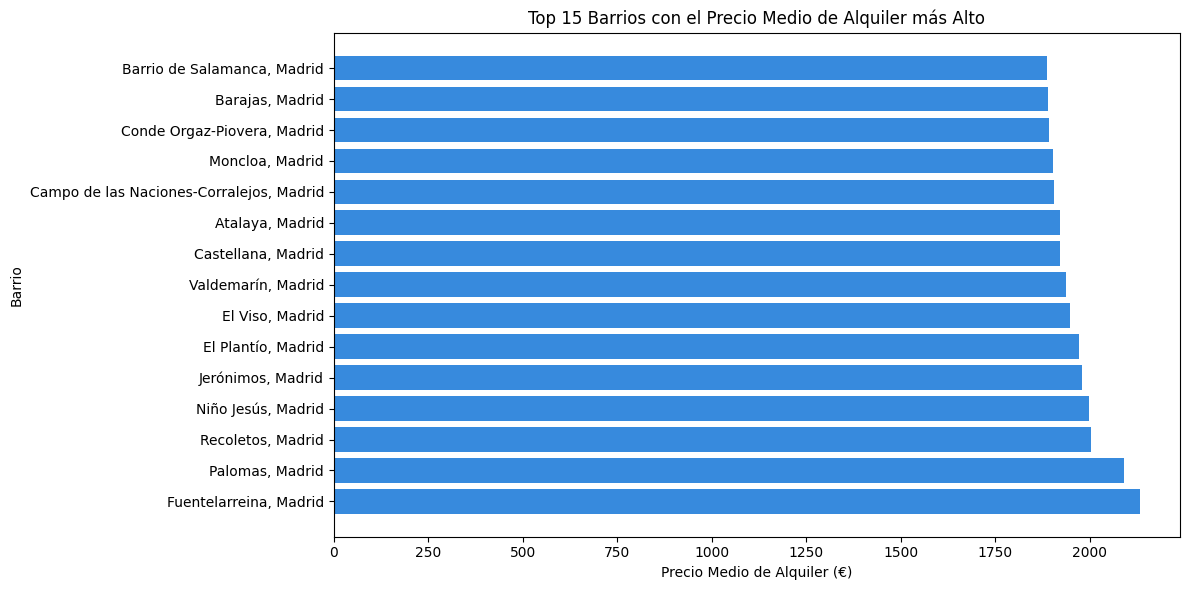

In [22]:
#importamos las librerías necesarias para la visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

#Calculamos la media de precio por barrio para ordenarlos en el gráfico y mostramos los 15 barrios con el precio medio más alto
top_barrios = df.groupby("barrio")["precio_alquiler"].mean().round(2).sort_values(ascending=False).head(15)

#Creamos un gráfico de barras para visualizar los precios medios por barrio
fig, ax= plt.subplots(figsize=(12, 6))

#Asignamos un color y titulos a los ejes y al gráfico
ax.barh(top_barrios.index, top_barrios.values, color="#378ADD")
ax.set_title("Top 15 Barrios con el Precio Medio de Alquiler más Alto")
ax.set_xlabel("Precio Medio de Alquiler (€)")
ax.set_ylabel("Barrio")

#Ajustamos el diseño para que no se solapen los elementos del gráfico
plt.tight_layout()

#Guardamos el gráfico en un archivo PNG
plt.savefig("E:/Archivos vscode/predictor-alquiler-madrid/visualizaciones/precio_medio_barrio_alto.png", dpi=300)

#Mostramos el gráfico
plt.show()

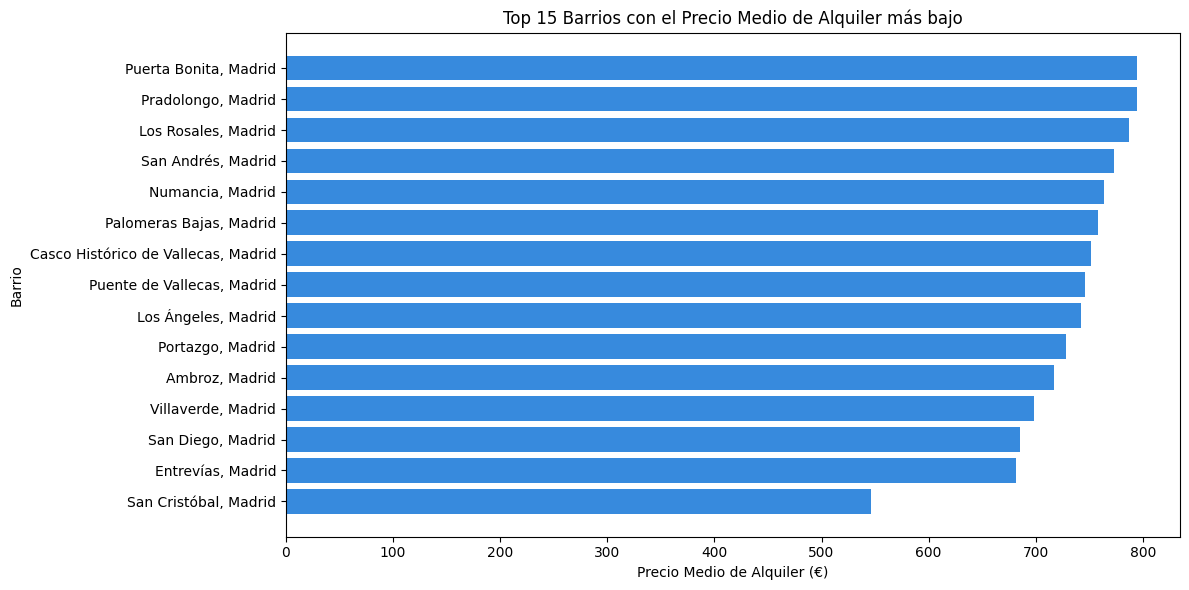

In [23]:

#Calculamos la media de precio por barrio para ordenarlos en el gráfico y mostramos los 15 barrios con el precio medio más bajo
low_barrios = df.groupby("barrio")["precio_alquiler"].mean().round(2).sort_values(ascending=True).head(15)

#Creamos un gráfico de barras para visualizar los precios medios por barrio
fig, ax= plt.subplots(figsize=(12, 6))

#Asignamos un color y titulos a los ejes y al gráfico
ax.barh(low_barrios.index, low_barrios.values, color="#378ADD")
ax.set_title("Top 15 Barrios con el Precio Medio de Alquiler más bajo")
ax.set_xlabel("Precio Medio de Alquiler (€)")
ax.set_ylabel("Barrio")

#Ajustamos el diseño para que no se solapen los elementos del gráfico
plt.tight_layout()

#Guardamos el gráfico en un archivo PNG
plt.savefig("E:/Archivos vscode/predictor-alquiler-madrid/visualizaciones/precio_medio_barrio_bajo.png", dpi=300)

#Mostramos el gráfico
plt.show()

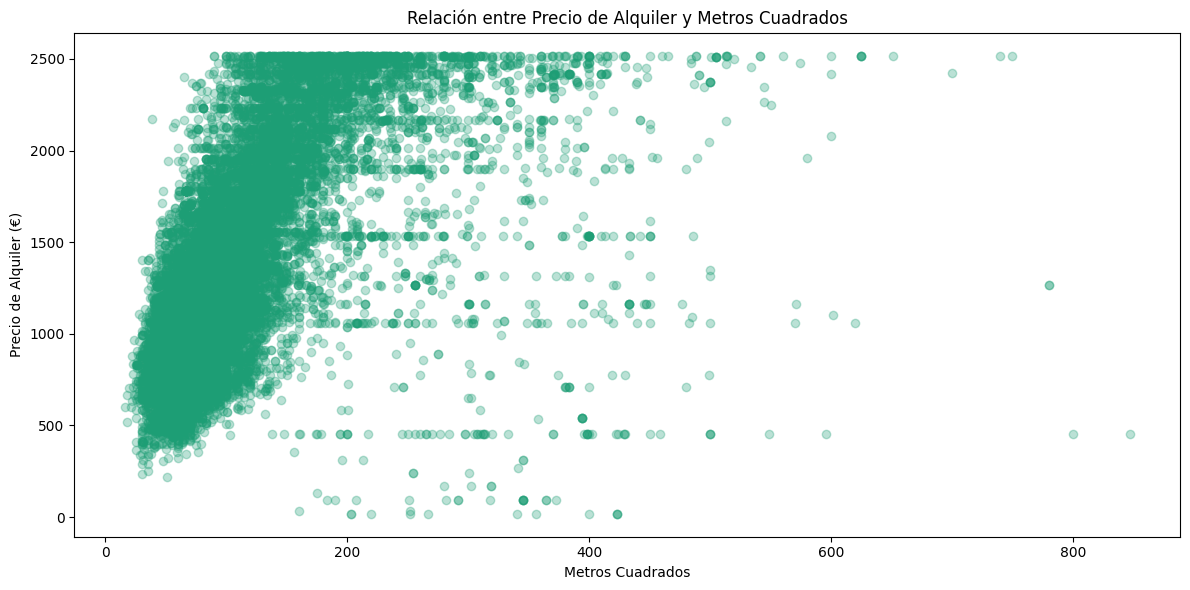

In [24]:
# Ahora vamos a crear un gráfico de dispersión para visualizar la relación entre el precio de alquiler y los metros cuadrados
fig, ax = plt.subplots(figsize=(12, 6))

#Creamos el gráfico de dispersión
ax.scatter(df['metros_cuadrados'],df['precio_alquiler'], alpha=0.3, color= '#1D9E75')

#Asignamos títulos a los ejes y al gráfico
ax.set_title("Relación entre Precio de Alquiler y Metros Cuadrados")    
ax.set_xlabel("Metros Cuadrados")
ax.set_ylabel("Precio de Alquiler (€)") 

#Ajustamos el diseño para que no se solapen los elementos del gráfico
plt.tight_layout()

#Guardamos el gráfico en un archivo PNG
plt.savefig("E:/Archivos vscode/predictor-alquiler-madrid/visualizaciones/dispersión_metros_precio.png", dpi=300)

#Mostramos el gráfico
plt.show()

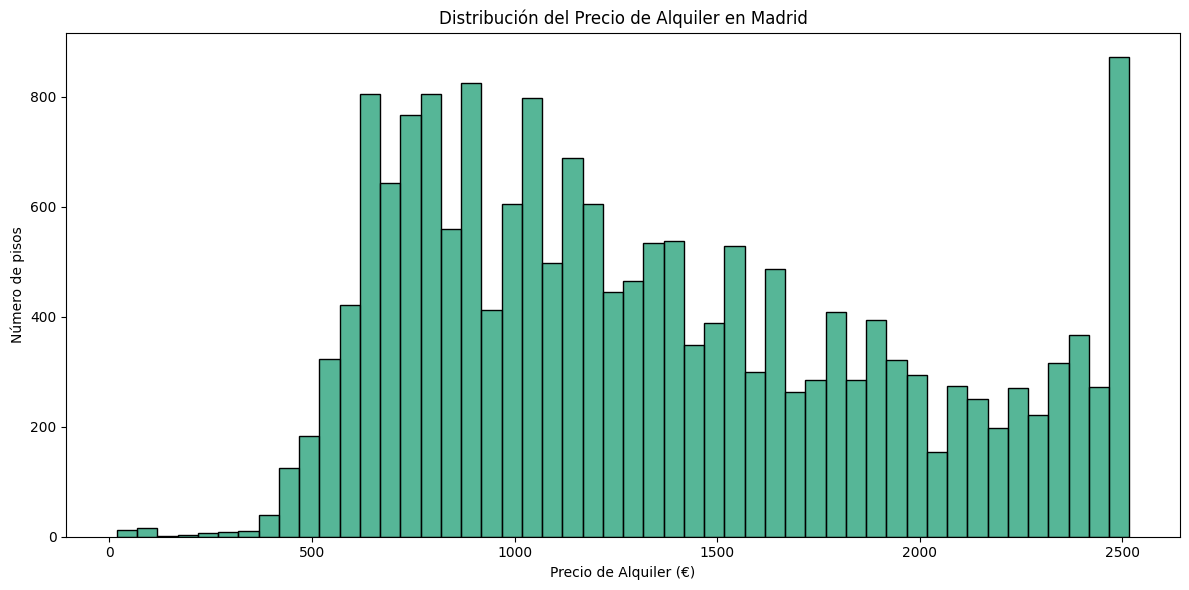

In [25]:
#Distribución del precio de alquiler
fig, ax = plt.subplots(figsize=(12, 6))

# Creamos un histograma para visualizar la distribución del precio de alquiler
sns.histplot(df['precio_alquiler'], bins=50,  color='#1D9E75', ax=ax)

#Asignamos títulos a los ejes y al gráfico
ax.set_title("Distribución del Precio de Alquiler en Madrid")
ax.set_xlabel("Precio de Alquiler (€)")
ax.set_ylabel("Número de pisos")

#Ajustamos el diseño para que no se solapen los elementos del gráfico
plt.tight_layout()  

#Guardamos el gráfico en un archivo PNG
plt.savefig("E:/Archivos vscode/predictor-alquiler-madrid/visualizaciones/distribución_precio_alquiler.png", dpi=300)

#Mostramos el gráfico
plt.show()  

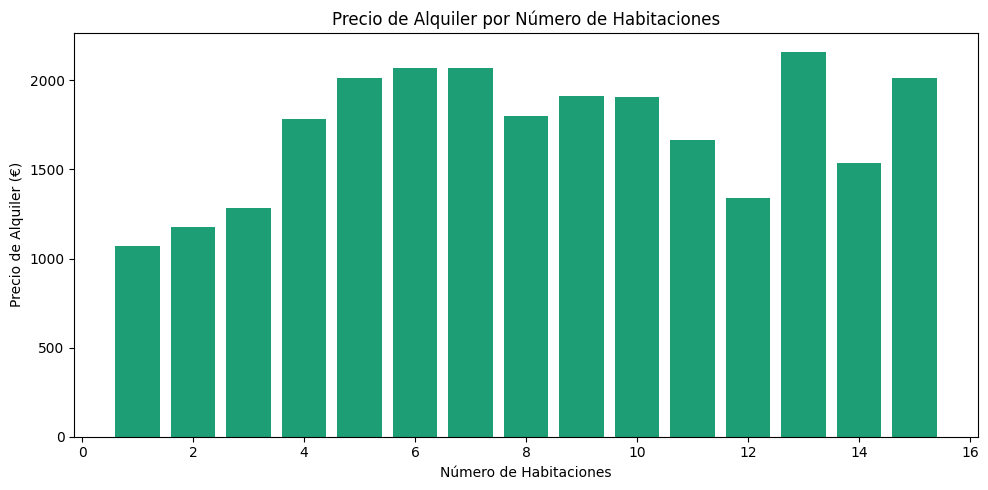

In [26]:
#Precio de alquiler por número de habitaciones
fig, ax = plt.subplots(figsize=(10, 5))
 
# Creamos un gráfico de caja barra para visualizar la distribución del precio de alquiler por número de habitaciones
precio_habitaciones = df.groupby("habitaciones")["precio_alquiler"].mean().round(2)
ax.bar(precio_habitaciones.index, precio_habitaciones.values, color="#1D9E75")

# Asignamos títulos a los ejes y al gráfico
ax.set_title("Precio de Alquiler por Número de Habitaciones")
ax.set_xlabel("Número de Habitaciones")
ax.set_ylabel("Precio de Alquiler (€)")

# Ajustamos el diseño para que no se solapen los elementos del gráfico
plt.tight_layout()

#Guardamos el gráfico en un archivo PNG
plt.savefig("E:/Archivos vscode/predictor-alquiler-madrid/visualizaciones/precio_alquiler_habitaciones.png", dpi=300)

# Mostramos el gráfico
plt.show()


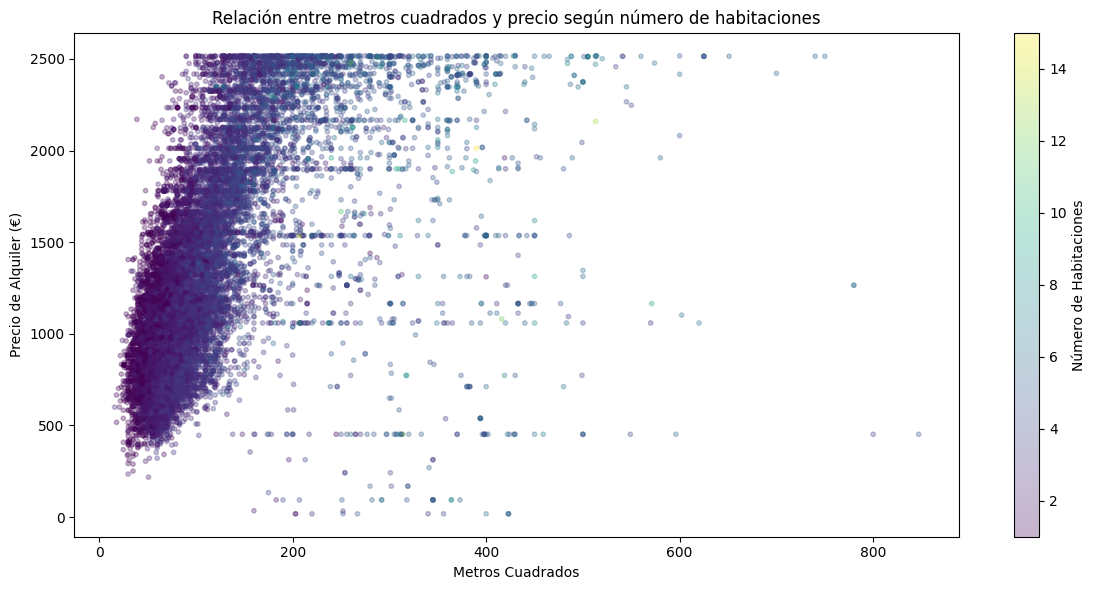

In [27]:
#Dispersión de metros cuadrados y precio coloreada por número de habitaciones
fig, ax = plt.subplots(figsize=(12, 6))

#Creamos el gráfico de dispersión coloreado por número de habitaciones
scatter = ax.scatter(df['metros_cuadrados'], df['precio_alquiler'], c=df['habitaciones'], cmap='viridis', alpha=0.3, s=10)

# Añadimos una barra de color para indicar el número de habitaciones
plt.colorbar(scatter, ax=ax , label='Número de Habitaciones')

# Asignamos títulos a los ejes y al gráfico
ax.set_title("Relación entre metros cuadrados y precio según número de habitaciones")
ax.set_xlabel("Metros Cuadrados")
ax.set_ylabel("Precio de Alquiler (€)")

# Ajustamos el diseño para que no se solapen los elementos del gráfico
plt.tight_layout()  

#Guardamos el gráfico en un archivo PNG
plt.savefig("E:/Archivos vscode/predictor-alquiler-madrid/visualizaciones/dispersión_metros_precio_habitaciones.png", dpi=300)

# Mostramos el gráfico
plt.show()  

In [28]:
#importamos la librería sklearn para comprobar su versión
import sklearn 
print(sklearn.__version__)

1.8.0


In [29]:
#Importamos la clase LabelEncoder de sklearn para codificar las variables categóricas
from sklearn.preprocessing import LabelEncoder

#Convertimos la columna barrio de texto a números utilizando LabelEncoder
la = LabelEncoder()
df["barrio_encoded"] = la.fit_transform(df["barrio"])

#Definimos la variables y el objetivo 
X = df[["metros_cuadrados", "habitaciones", "barrio_encoded"]]
y = df["precio_alquiler"]

#Mostramos las varibles y el objetivo para verificar que se han definido correctamente
print(f"Features: ´{X.shape}")
print(f"Target: {y.shape}")




Features: ´(18660, 3)
Target: (18660,)


In [30]:
#Importamos la libreria train_test_split de sklearn para dividir el dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Dividimos los datos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Mostramos las formas de los conjuntos de entrenamiento y prueba para verificar que se han dividido correctamente
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (14928, 3)
X_test: (3732, 3)


In [31]:
#Importamos el ensamble RandomForestRegressor de sklearn para crear el modelo de regresión
from sklearn.ensemble import RandomForestRegressor

#Creamos el modelo Random Forest
modelo = RandomForestRegressor(n_estimators=100, random_state=42)

#Entrenamos el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

#Evaluamos el modelo con los datos de prueba
print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [32]:
#Importamos metrics de sklearn y mean_absolute_error para evaluar el rendimiento del modelo
from sklearn.metrics import mean_absolute_error, r2_score

#Hacemos predicciones con el modelo entrenado
y_pred = modelo.predict(X_test)

#Calculamos el error absoluto 
mae = mean_absolute_error(y_test, y_pred)

#Calculamos el coeficiente de determinación R^2
r2 = r2_score(y_test, y_pred)

#Mostramos los resultados de la evaluación del modelo
print(f"Error medio absoluto (MAE): {mae:.2f} €")
print(f"R^2: {r2:.4f}")

Error medio absoluto (MAE): 177.00 €
R^2: 0.7861


In [33]:
#Importamos pickle para guardar el modelo entrenado
import pickle

#Guardamos el modelo entrenado en un archivo
with open("E:/Archivos vscode/predictor-alquiler-madrid/models/model.pkl", "wb") as f:
    pickle.dump(modelo, f)

#Guardamos el LabelEncoder para poder usarlo en la app
with open("E:/Archivos vscode/predictor-alquiler-madrid/models/label_encoder.pkl", "wb") as f:
    pickle.dump(la, f)

#Mostramos un mensaje indicando que el modelo y el LabelEncoder se han guardado correctamente
print("Modelo y LabelEncoder guardados correctamente")

Modelo y LabelEncoder guardados correctamente


In [34]:
# Probamos el modelo con un piso inventado
# 80 metros cuadrados, 2 habitaciones en Salamanca
barrio_test = la.transform(['Barrio de Salamanca, Madrid'])

piso_prueba = pd.DataFrame({
    'metros_cuadrados': [80],
    'habitaciones': [2],
    'barrio_encoded': [barrio_test[0]]
})

prediccion = modelo.predict(piso_prueba)
print(f"Precio predicho: {prediccion[0]:.2f}€")



Precio predicho: 1587.71€
